In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

base_path = 'data' if os.path.exists('data') else 'clustering/data'
df_sintetico = pd.read_csv(os.path.join(base_path, 'datos_embarazo_sintetico.csv'))
df_meta = pd.read_csv(os.path.join(base_path, 'metadatos_ground_truth.csv'))
df = df_sintetico.merge(df_meta, on='paciente_id')

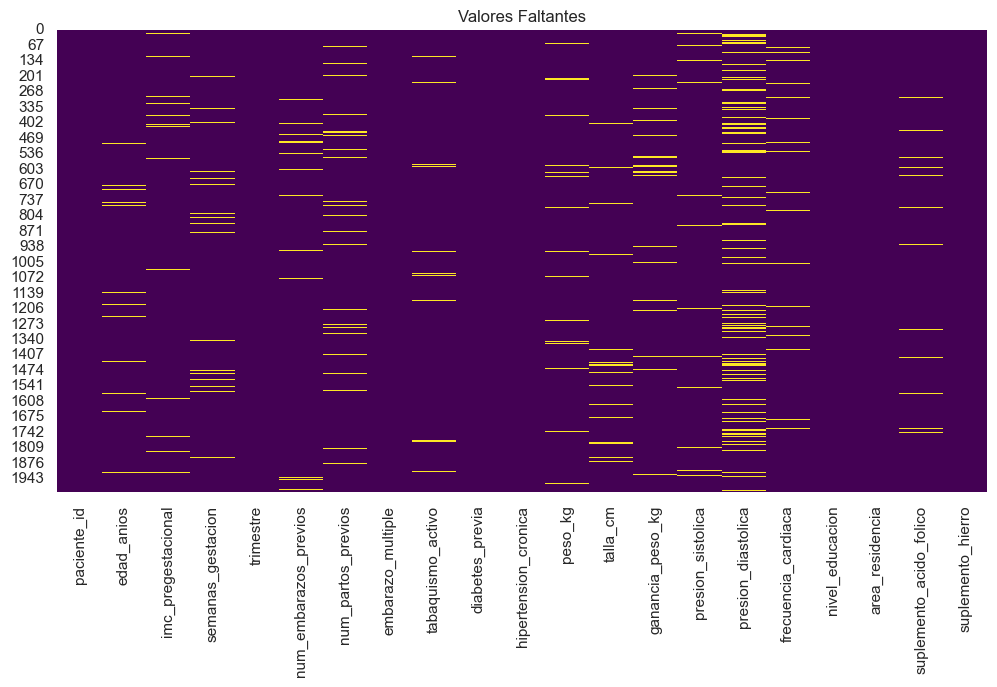

In [4]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_sintetico.isna(), cbar=False, cmap='viridis')
plt.title('Valores Faltantes')
plt.show()

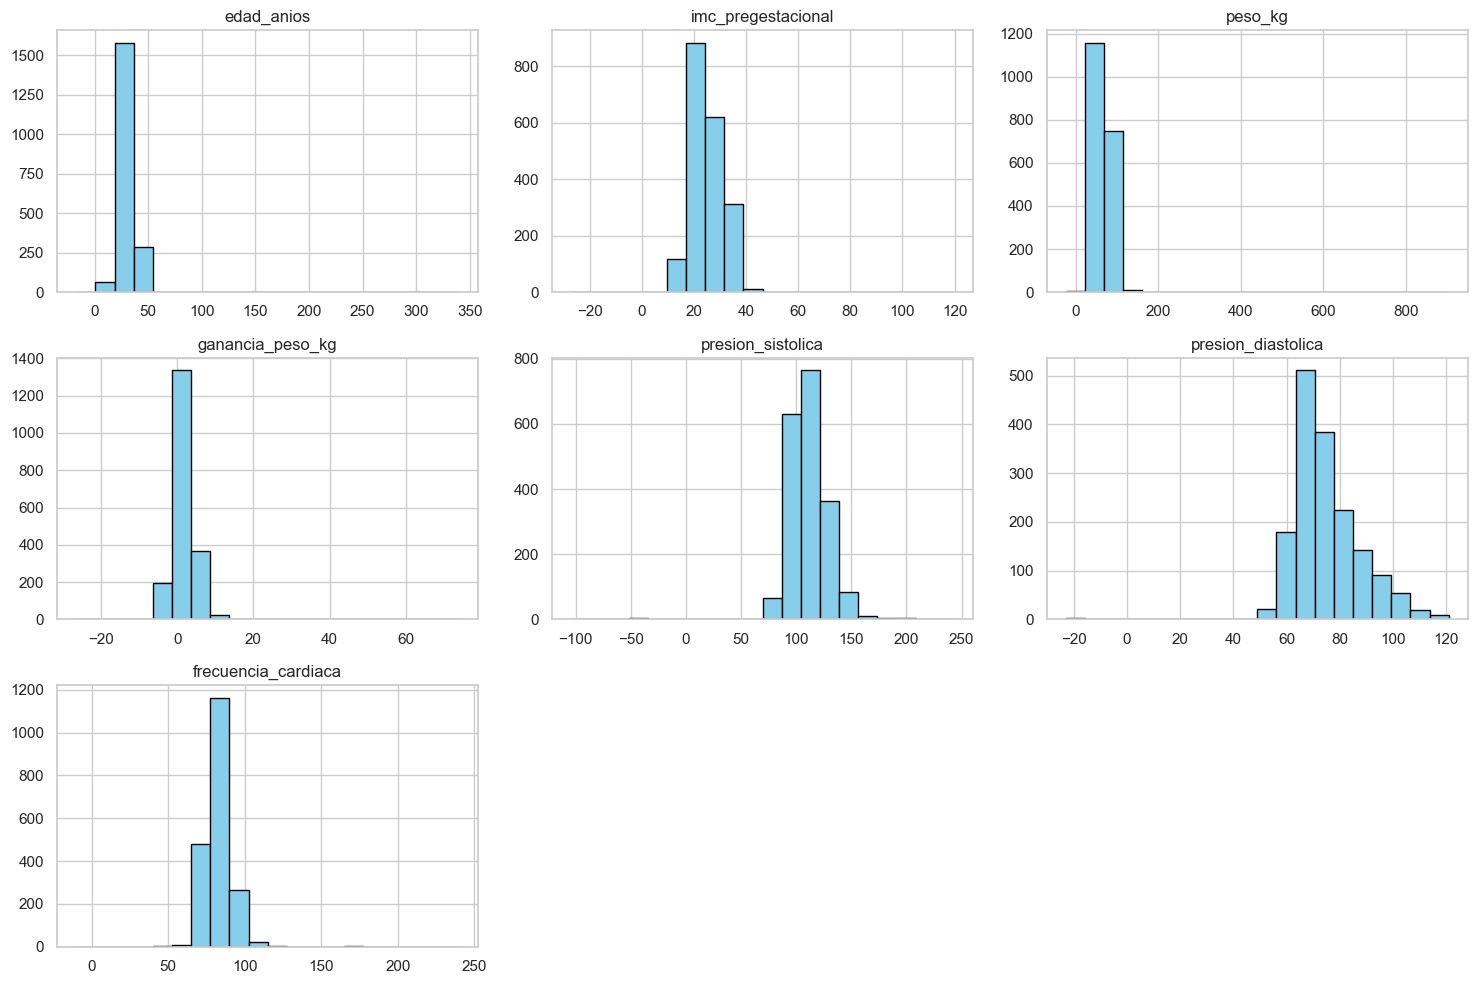

In [5]:
cols_continuas = ['edad_anios', 'imc_pregestacional', 'peso_kg', 'ganancia_peso_kg', 
                  'presion_sistolica', 'presion_diastolica', 'frecuencia_cardiaca']
df_sintetico[cols_continuas].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

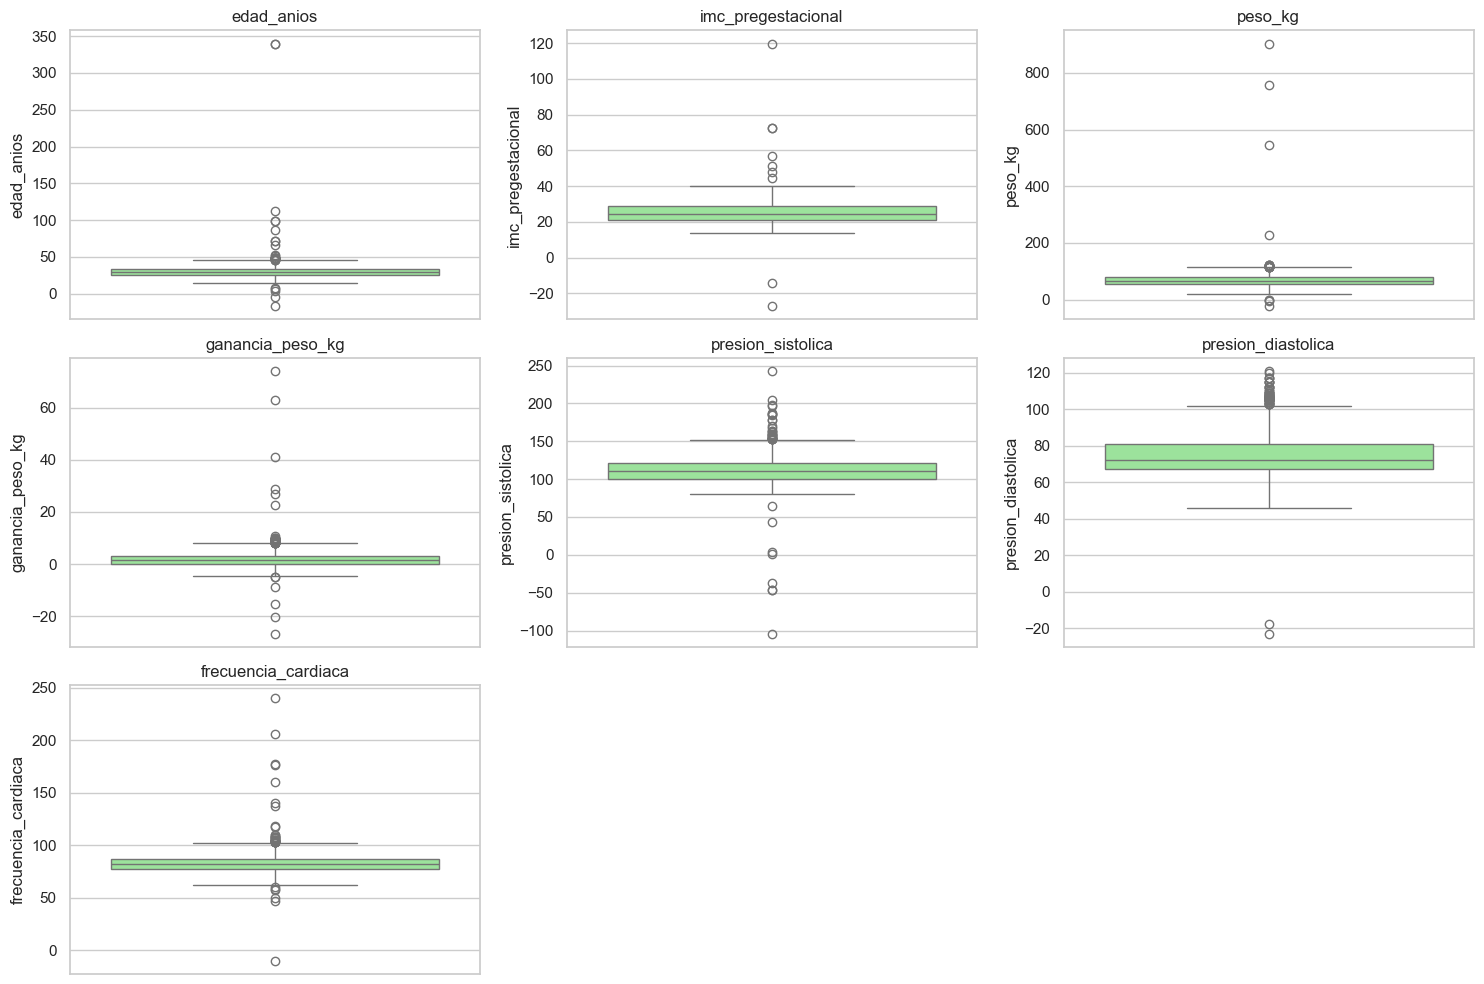

In [6]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_continuas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_sintetico[col], color='lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

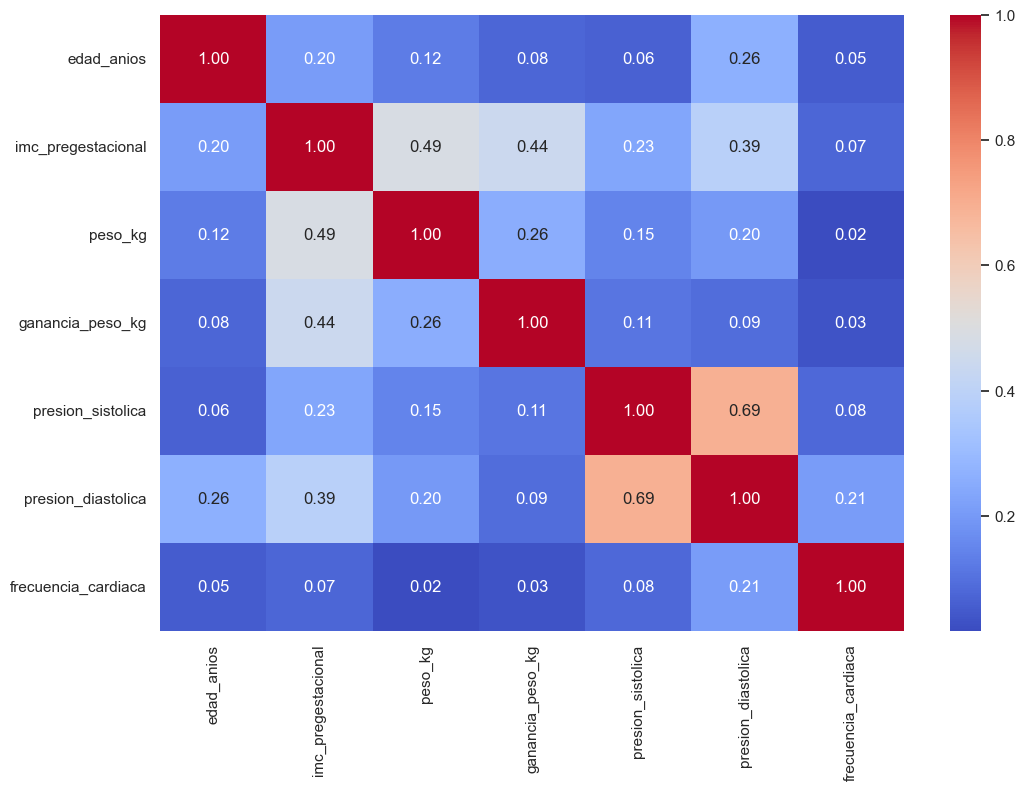

In [7]:
plt.figure(figsize=(12, 8))
corr = df_sintetico[cols_continuas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

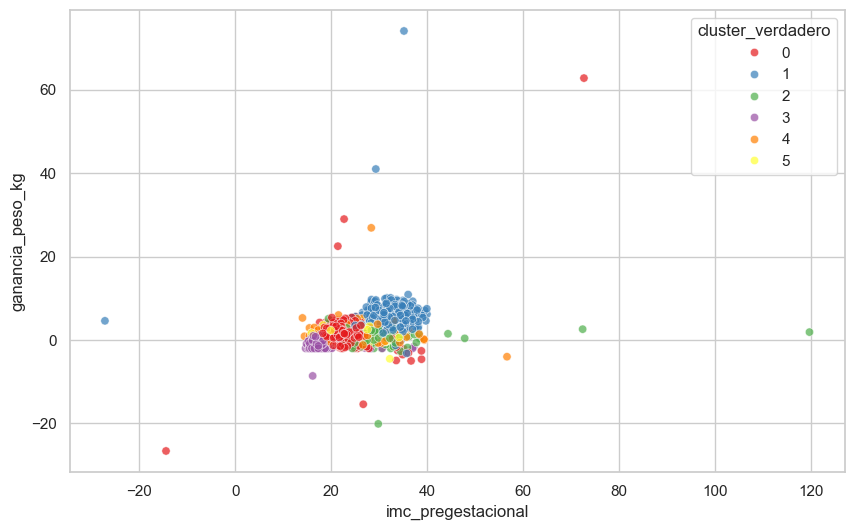

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='imc_pregestacional', y='ganancia_peso_kg', 
                hue='cluster_verdadero', palette='Set1', alpha=0.7)
plt.show()

C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_7556\451242745.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sintetico, x=col, palette='pastel')
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_7556\451242745.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sintetico, x=col, palette='pastel')
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_7556\451242745.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sintetico, x=col, palette='pastel')
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_7556\451

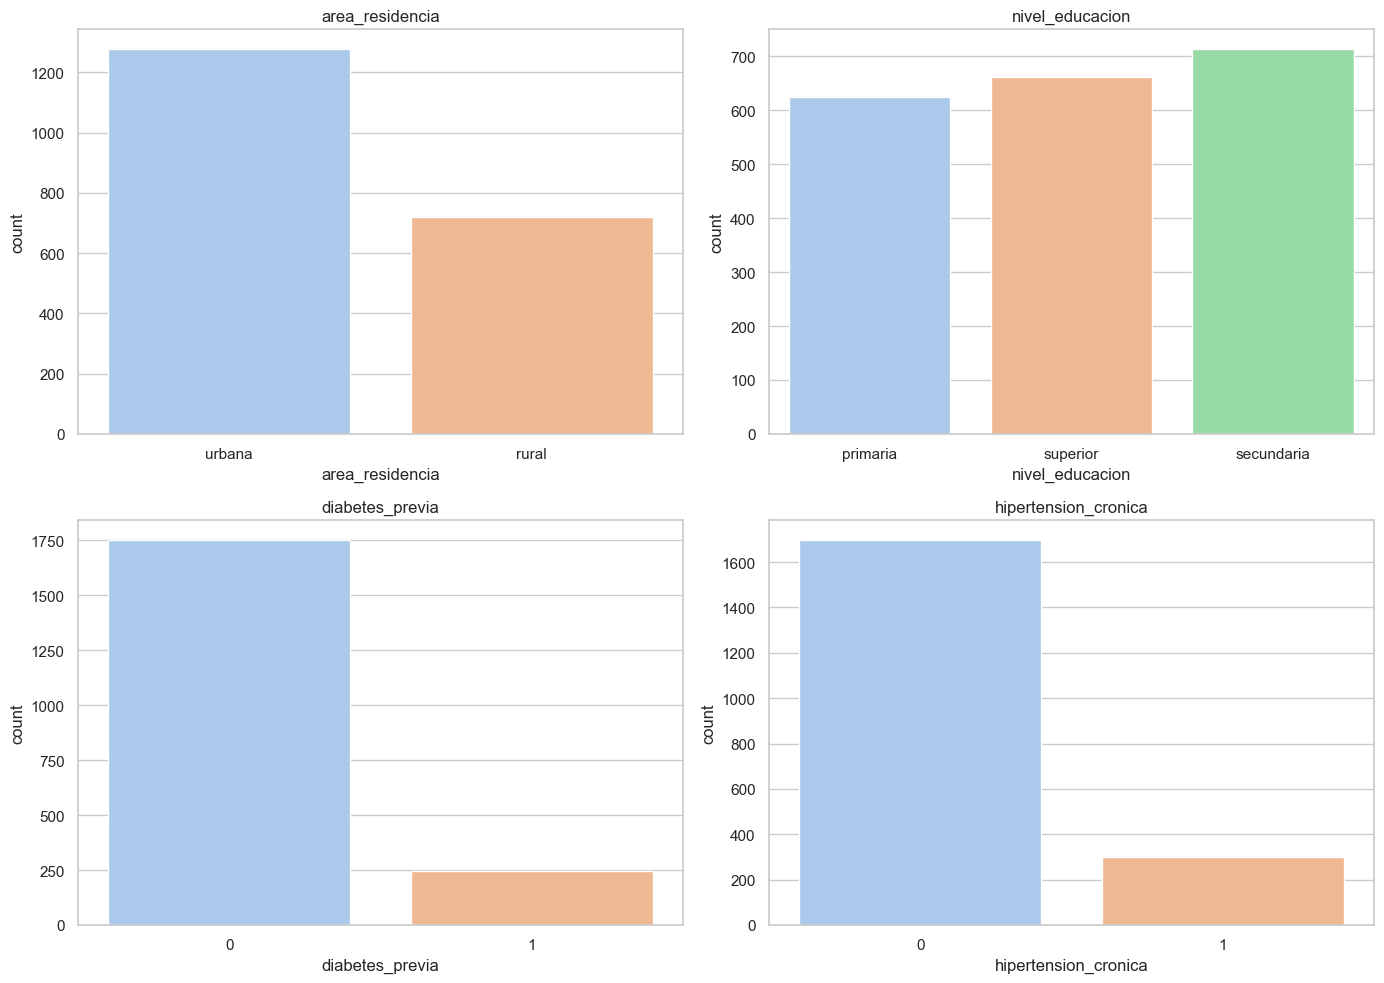

In [9]:
cols_cat = ['area_residencia', 'nivel_educacion', 'diabetes_previa', 'hipertension_cronica']
plt.figure(figsize=(14, 10))
for i, col in enumerate(cols_cat, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df_sintetico, x=col, palette='pastel')
    plt.title(col)
plt.tight_layout()
plt.show()